In [1]:
# ==================== PARAMETERS ====================

# Đường dẫn dữ liệu đã feature engineering từ notebook 03
INPUT_DATA_PATH = "data/processed/feature_engineered_data.parquet"

# Thư mục lưu kết quả
OUTPUT_DIR = "data/processed"

# Tên file output
ETS_RESULTS_FILENAME = "ets_results.csv"
ETS_METRICS_FILENAME = "ets_metrics.csv"

# Cột mục tiêu (cần dự báo)
TARGET_COLUMN = "Global_active_power"

# Tỷ lệ tập test (20% dữ liệu cuối)
TEST_SIZE = 0.2

# Tham số ETS (Holt-Winters)
SEASONAL_PERIODS = 24      # Chu kỳ mùa vụ (24 giờ)
TREND = "add"              # 'add' hoặc None
SEASONAL = "add"           # 'add' hoặc None

# Bật/tắt các biểu đồ
PLOT_ETS_FORECAST = True
PLOT_RESIDUALS = True

In [2]:
# Parameters
INPUT_DATA_PATH = "data/processed/feature_engineered_data.parquet"
OUTPUT_DIR = "data/processed"
ETS_RESULTS_FILENAME = "ets_results.csv"
ETS_METRICS_FILENAME = "ets_metrics.csv"
ETS_MODEL_INFO_FILENAME = "ets_model_info.json"
TARGET_COLUMN = "Global_active_power"
TEST_SIZE = 0.2
SEASONAL_PERIOD = 24
TREND_COMPONENT = True
SEASONAL_COMPONENT = True
DAMPED_TREND = False
INITIALIZATION_METHOD = "estimated"
PLOT_ETS_FORECAST = True
PLOT_RESIDUALS = True
PLOT_COMPONENTS = True
PLOT_COMPARISON = True


In [3]:
# ==================== SETUP ====================
%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Xác định project_root linh hoạt
cwd = os.getcwd()
if os.path.basename(cwd) == "notebooks":
    project_root = os.path.abspath("..")
else:
    project_root = cwd

src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.append(src_path)

# Import thư viện tự viết - SimpleETS
try:
    from src.simple_arima import SimpleETS, calculate_mae, calculate_rmse, calculate_smape
    SIMPLE_ETS_AVAILABLE = True
    print("✅ SimpleETS đã sẵn sàng!")
except ImportError as e:
    print(f"⚠️ Lỗi import SimpleETS: {e}")
    print("   Vui lòng đảm bảo file src/simple_arima.py tồn tại")
    SIMPLE_ETS_AVAILABLE = False

# Import thư viện tự viết khác
from src.energy_forecast_library import DataLoader, Utils

# Tạo thư mục output nếu chưa có
os.makedirs(os.path.join(project_root, OUTPUT_DIR), exist_ok=True)
os.makedirs(os.path.join(project_root, "outputs/figures"), exist_ok=True)

print(f"✅ Project root: {project_root}")
print(f"✅ Output dir: {OUTPUT_DIR}")

✅ SimpleETS đã sẵn sàng!
✅ Project root: C:\Users\Admin\DataMining\nhom_13_Household_Power
✅ Output dir: data/processed


In [4]:
# ==================== LOAD DATA ====================
data_path = os.path.join(project_root, INPUT_DATA_PATH)

if not os.path.exists(data_path):
    print(f"❌ Không tìm thấy file: {data_path}")
    print("Vui lòng chạy notebook 03 trước!")
else:
    df = DataLoader.load_processed_data(data_path)
    
    print(f"✅ Đã tải dữ liệu từ: {INPUT_DATA_PATH}")
    print(f"📊 Kích thước: {df.shape[0]:,} dòng, {df.shape[1]} cột")
    print(f"📅 Thời gian: {df.index.min()} → {df.index.max()}")
    print(f"📌 Cột mục tiêu: {TARGET_COLUMN}")
    
    df.head()

✅ Đã đọc 2,048,913 dòng từ feature_engineered_data.parquet
✅ Đã tải dữ liệu từ: data/processed/feature_engineered_data.parquet
📊 Kích thước: 2,048,913 dòng, 48 cột
📅 Thời gian: 2006-12-16 18:12:00 → 2010-11-26 21:02:00
📌 Cột mục tiêu: Global_active_power


📊 Chia dữ liệu train/test theo thời gian...
📌 Tỷ lệ test: 20%

✅ Train: 1,639,130 samples (2006-12-16 18:12:00 → 2010-02-05 04:25:00)
✅ Test: 409,783 samples (2010-02-05 04:26:00 → 2010-11-26 21:02:00)


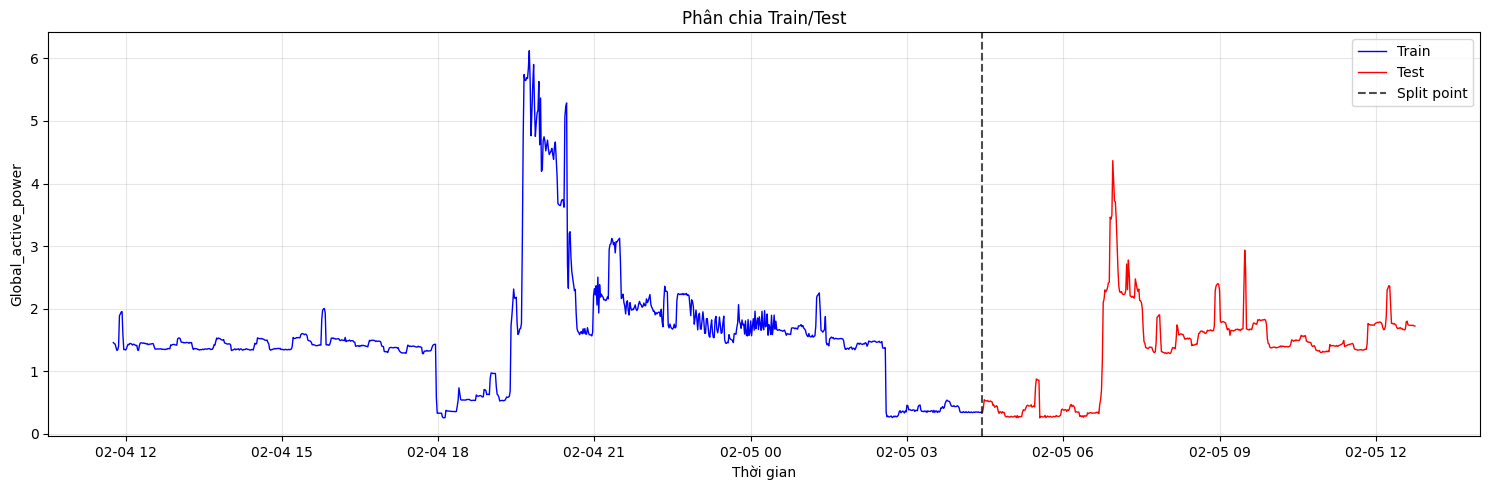

In [5]:
# ==================== CHIA TRAIN/TEST ====================
print("📊 Chia dữ liệu train/test theo thời gian...")
print(f"📌 Tỷ lệ test: {TEST_SIZE*100:.0f}%")

# Chia dữ liệu theo thời gian
n = len(df)
split_idx = int(n * (1 - TEST_SIZE))

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

y_train = train[TARGET_COLUMN]
y_test = test[TARGET_COLUMN]

print(f"\n✅ Train: {len(y_train):,} samples ({train.index[0]} → {train.index[-1]})")
print(f"✅ Test: {len(y_test):,} samples ({test.index[0]} → {test.index[-1]})")

# Vẽ biểu đồ chia train/test
fig, ax = plt.subplots(figsize=(15, 5))

# Lấy mẫu để vẽ (1000 điểm cuối train + 500 điểm đầu test)
train_sample = y_train.iloc[-1000:] if len(y_train) > 1000 else y_train
test_sample = y_test.iloc[:500] if len(y_test) > 500 else y_test

ax.plot(train_sample.index, train_sample.values, color='blue', linewidth=1, label='Train')
ax.plot(test_sample.index, test_sample.values, color='red', linewidth=1, label='Test')
ax.axvline(x=y_test.index[0], color='black', linestyle='--', alpha=0.7, label='Split point')
ax.set_xlabel('Thời gian')
ax.set_ylabel(TARGET_COLUMN)
ax.set_title('Phân chia Train/Test')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# ==================== HUẤN LUYỆN SIMPLE ETS ====================
if not SIMPLE_ETS_AVAILABLE:
    print("❌ Không thể huấn luyện do thiếu SimpleETS")
else:
    print("📈 Đang huấn luyện mô hình SimpleETS (Holt-Winters) tự viết...")
    print(f"📌 Seasonal periods: {SEASONAL_PERIODS}")
    print(f"📌 Trend: {TREND}")
    print(f"📌 Seasonal: {SEASONAL}")
    
    import time
    start_time = time.time()
    
    try:
        # Khởi tạo mô hình SimpleETS
        model = SimpleETS(
            seasonal_periods=SEASONAL_PERIODS,
            trend=TREND,
            seasonal=SEASONAL
        )
        
        # Huấn luyện
        model.fit(y_train)
        training_time = time.time() - start_time
        print(f"\n⏱️ Thời gian huấn luyện: {training_time:.2f} giây")
        
        # Dự báo
        y_pred = model.predict(len(y_test))
        
        # Tạo DataFrame kết quả
        results_df = pd.DataFrame({
            'timestamp': y_test.index,
            'actual': y_test.values,
            'ets_pred': y_pred
        })
        
        print("\n✅ 5 dòng đầu kết quả dự báo:")
        results_df.head(10)
        
    except Exception as e:
        print(f"❌ Lỗi khi huấn luyện SimpleETS: {e}")
        import traceback
        traceback.print_exc()
        model = None
        y_pred = np.array([np.nan] * len(y_test))

📈 Đang huấn luyện mô hình SimpleETS (Holt-Winters) tự viết...
📌 Seasonal periods: 24
📌 Trend: add
📌 Seasonal: add



⏱️ Thời gian huấn luyện: 0.56 giây

✅ 5 dòng đầu kết quả dự báo:


In [7]:
# ==================== ĐÁNH GIÁ MÔ HÌNH ====================
if SIMPLE_ETS_AVAILABLE and model is not None and not np.isnan(y_pred).all():
    # Tính các metrics
    mae = calculate_mae(y_test.values, y_pred)
    rmse = calculate_rmse(y_test.values, y_pred)
    smape = calculate_smape(y_test.values, y_pred)
    
    print("="*50)
    print("📊 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH SIMPLE ETS")
    print("="*50)
    print(f"✅ MAE  (Mean Absolute Error): {mae:.4f}")
    print(f"✅ RMSE (Root Mean Square Error): {rmse:.4f}")
    print(f"✅ SMAPE (Symmetric MAPE): {smape:.2f}%")
    print("="*50)
    
    # Lưu metrics
    metrics_dict = {
        'model': 'SimpleETS',
        'seasonal_periods': SEASONAL_PERIODS,
        'trend': TREND,
        'seasonal': SEASONAL,
        'mae': mae,
        'rmse': rmse,
        'smape': smape,
        'training_time': training_time,
        'test_size': len(y_test),
        'train_size': len(y_train)
    }
    
    metrics_df = pd.DataFrame([metrics_dict])
    metrics_df
else:
    print("⚠️ Không thể đánh giá do mô hình không chạy được")
    mae = rmse = smape = np.nan

📊 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH SIMPLE ETS
✅ MAE  (Mean Absolute Error): 0.7324
✅ RMSE (Root Mean Square Error): 0.9046
✅ SMAPE (Symmetric MAPE): 74.85%


In [8]:
# ==================== SO SÁNH VỚI BASELINE VÀ ARIMA ====================
# Đọc kết quả từ các notebook trước
baseline_path = os.path.join(project_root, OUTPUT_DIR, 'baseline_metrics.csv')
arima_path = os.path.join(project_root, OUTPUT_DIR, 'arima_metrics.csv')

comparison_data = []

# Thêm ETS
if not np.isnan(mae):
    comparison_data.append({
        'Model': 'SimpleETS',
        'MAE': mae,
        'RMSE': rmse,
        'SMAPE': smape
    })

# Thêm Baseline nếu có
if os.path.exists(baseline_path):
    baseline = pd.read_csv(baseline_path)
    comparison_data.append({
        'Model': 'Baseline',
        'MAE': baseline['mae'].values[0],
        'RMSE': baseline['rmse'].values[0],
        'SMAPE': baseline['smape'].values[0]
    })

# Thêm ARIMA nếu có
if os.path.exists(arima_path):
    arima = pd.read_csv(arima_path)
    comparison_data.append({
        'Model': 'SimpleARIMA',
        'MAE': arima['mae'].values[0],
        'RMSE': arima['rmse'].values[0],
        'SMAPE': arima['smape'].values[0]
    })

# Tạo DataFrame so sánh
if comparison_data:
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('RMSE')
    
    print("📊 SO SÁNH CÁC MÔ HÌNH")
    print("="*60)
    print(comparison_df.to_string(index=False))
    
    # Tìm mô hình tốt nhất
    best_model = comparison_df.iloc[0]['Model']
    best_rmse = comparison_df.iloc[0]['RMSE']
    print(f"\n🏆 Mô hình tốt nhất: {best_model} (RMSE = {best_rmse:.4f})")

📊 SO SÁNH CÁC MÔ HÌNH
      Model      MAE     RMSE      SMAPE
  SimpleETS 0.732405 0.904589  74.847357
   Baseline 0.717032 1.120147  74.583736
SimpleARIMA 0.912105 1.279171 141.387034

🏆 Mô hình tốt nhất: SimpleETS (RMSE = 0.9046)


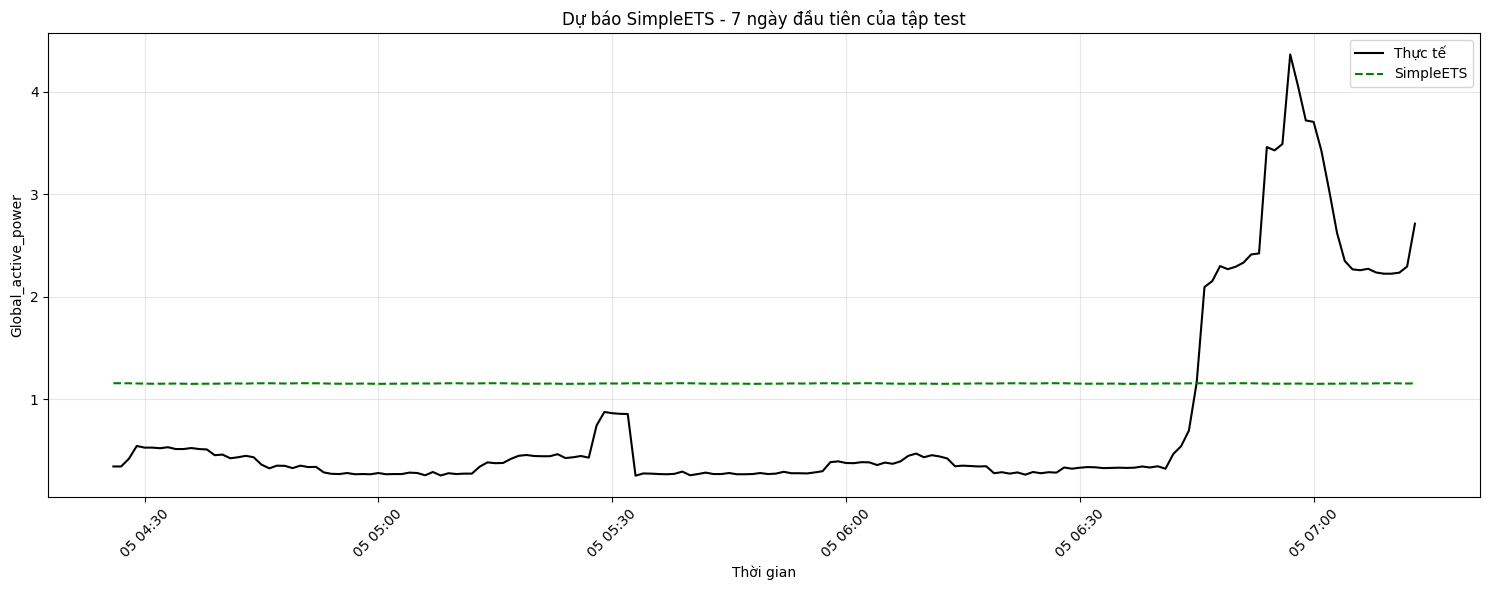

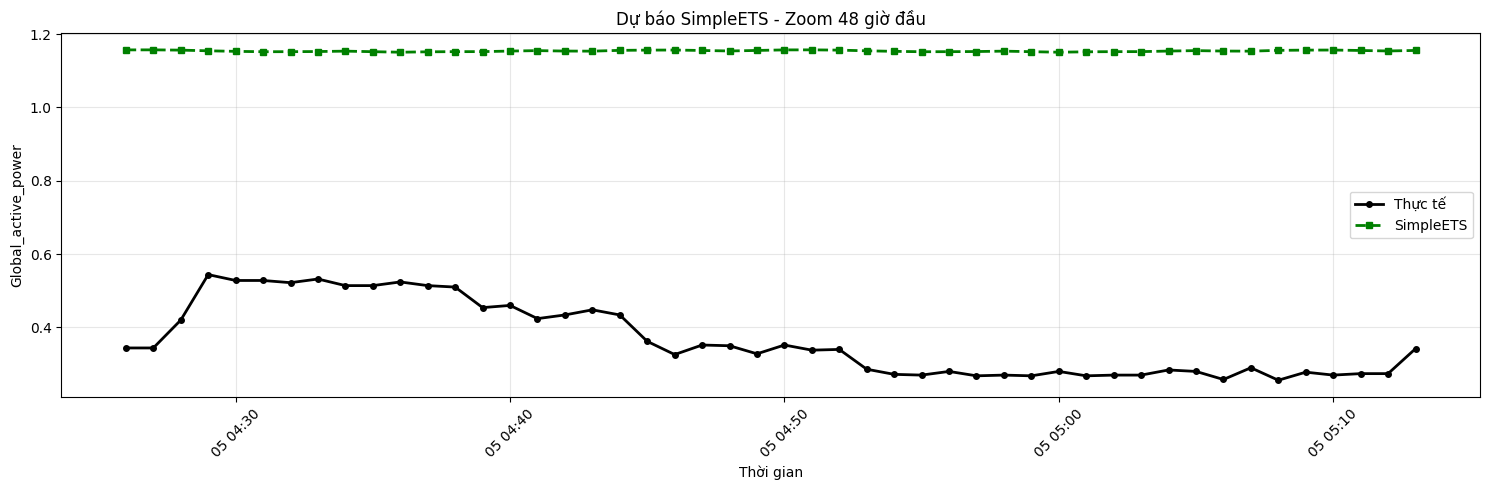

In [9]:
# ==================== VẼ BIỂU ĐỒ DỰ BÁO ====================
if PLOT_ETS_FORECAST and not np.isnan(y_pred).all():
    # QUAN TRỌNG: Convert timestamp về datetime
    results_df['timestamp'] = pd.to_datetime(results_df['timestamp'])
    
    # Lấy mẫu 7 ngày đầu của test để dễ nhìn
    sample_days = 7
    sample_points = min(sample_days * 24, len(results_df))
    
    sample_results = results_df.iloc[:sample_points].copy()
    
    fig, ax = plt.subplots(figsize=(15, 6))
    
    ax.plot(sample_results['timestamp'], sample_results['actual'], 
            color='black', linewidth=1.5, label='Thực tế')
    ax.plot(sample_results['timestamp'], sample_results['ets_pred'], 
            color='green', linestyle='--', linewidth=1.5, label='SimpleETS')
    
    ax.set_xlabel('Thời gian')
    ax.set_ylabel(TARGET_COLUMN)
    ax.set_title(f'Dự báo SimpleETS - {sample_days} ngày đầu tiên của tập test')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'outputs/figures/simple_ets_forecast.png'), 
                dpi=100, bbox_inches='tight')
    plt.show()
    
    # Vẽ zoom 48 giờ đầu
    fig, ax = plt.subplots(figsize=(15, 5))
    
    zoom_results = results_df.iloc[:min(48, len(results_df))].copy()
    
    ax.plot(zoom_results['timestamp'], zoom_results['actual'], 
            color='black', linewidth=2, marker='o', markersize=4, label='Thực tế')
    ax.plot(zoom_results['timestamp'], zoom_results['ets_pred'], 
            color='green', linestyle='--', linewidth=2, marker='s', markersize=4, label='SimpleETS')
    
    ax.set_xlabel('Thời gian')
    ax.set_ylabel(TARGET_COLUMN)
    ax.set_title('Dự báo SimpleETS - Zoom 48 giờ đầu')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'outputs/figures/simple_ets_zoom.png'), 
                dpi=100, bbox_inches='tight')
    plt.show()

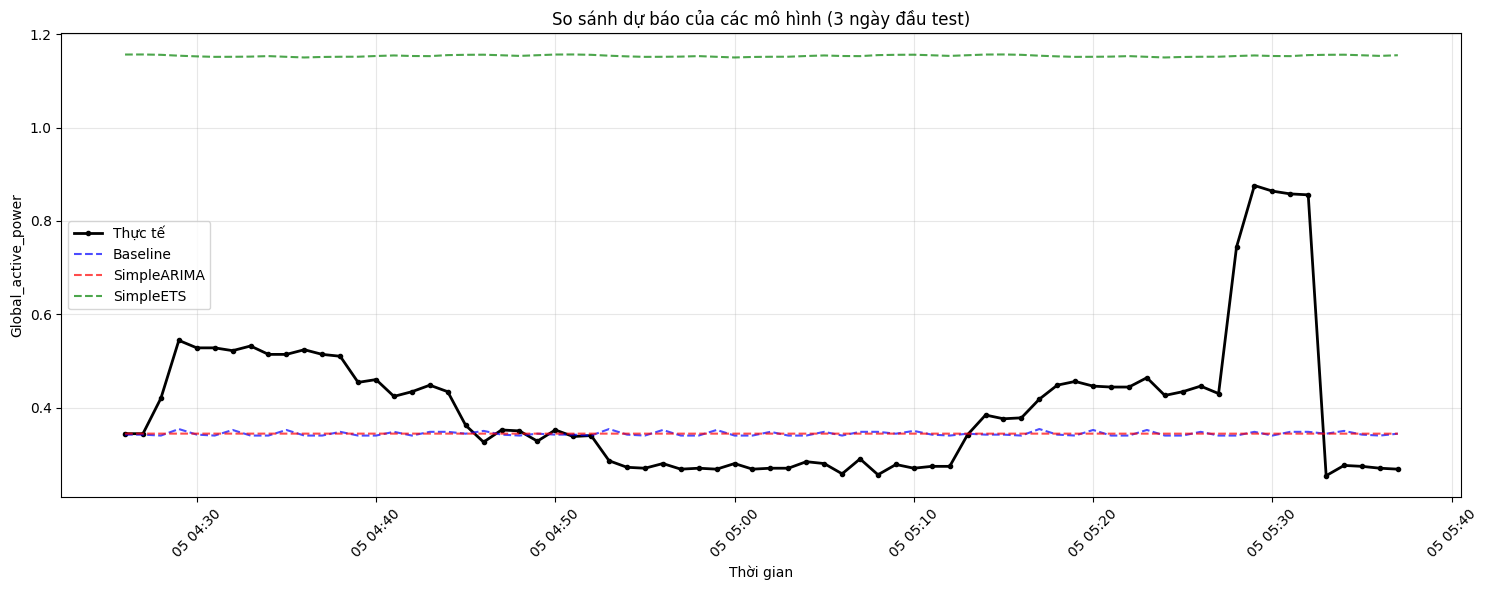

In [10]:
# ==================== VẼ SO SÁNH TẤT CẢ MÔ HÌNH ====================
if not np.isnan(y_pred).all():
    fig, ax = plt.subplots(figsize=(15, 6))
    
    # Lấy mẫu 3 ngày
    sample_points = min(72, len(results_df))  # 3 ngày = 72 giờ
    sample_results = results_df.iloc[:sample_points].copy()
    
    # QUAN TRỌNG: Convert timestamp về datetime
    sample_results['timestamp'] = pd.to_datetime(sample_results['timestamp'])
    
    ax.plot(sample_results['timestamp'], sample_results['actual'], 
            color='black', linewidth=2, label='Thực tế', marker='o', markersize=3)
    
    # Thêm baseline nếu có
    baseline_results_path = os.path.join(project_root, OUTPUT_DIR, 'baseline_results.csv')
    if os.path.exists(baseline_results_path):
        baseline_results = pd.read_csv(baseline_results_path)
        baseline_results = baseline_results.iloc[:sample_points].copy()
        # QUAN TRỌNG: Convert timestamp về datetime
        baseline_results['timestamp'] = pd.to_datetime(baseline_results['timestamp'])
        ax.plot(baseline_results['timestamp'], baseline_results['baseline_pred'], 
                color='blue', linestyle='--', linewidth=1.5, label='Baseline', alpha=0.7)
    
    # Thêm ARIMA nếu có
    arima_results_path = os.path.join(project_root, OUTPUT_DIR, 'arima_results.csv')
    if os.path.exists(arima_results_path):
        arima_results = pd.read_csv(arima_results_path)
        arima_results = arima_results.iloc[:sample_points].copy()
        # QUAN TRỌNG: Convert timestamp về datetime
        arima_results['timestamp'] = pd.to_datetime(arima_results['timestamp'])
        ax.plot(arima_results['timestamp'], arima_results['arima_pred'], 
                color='red', linestyle='--', linewidth=1.5, label='SimpleARIMA', alpha=0.7)
    
    # Thêm ETS
    ax.plot(sample_results['timestamp'], sample_results['ets_pred'], 
            color='green', linestyle='--', linewidth=1.5, label='SimpleETS', alpha=0.7)
    
    ax.set_xlabel('Thời gian')
    ax.set_ylabel(TARGET_COLUMN)
    ax.set_title('So sánh dự báo của các mô hình (3 ngày đầu test)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'outputs/figures/model_comparison.png'), 
                dpi=100, bbox_inches='tight')
    plt.show()

In [11]:
# ==================== PHÂN TÍCH PHẦN DƯ ====================
if not np.isnan(y_pred).all():
    residuals = y_test.values - y_pred
    
    print("📊 Phân tích phần dư (Residuals) - ETS:")
    print(f"   - Mean: {np.mean(residuals):.4f}")
    print(f"   - Std: {np.std(residuals):.4f}")
    print(f"   - Min: {np.min(residuals):.4f}")
    print(f"   - Max: {np.max(residuals):.4f}")
    
    if abs(np.mean(residuals)) < 0.1:
        print("✅ Residual mean gần 0 - tốt")
    else:
        print("⚠️ Residual mean khác 0 - mô hình có thể bị bias")
        
    if abs(pd.Series(residuals).skew()) < 0.5:
        print("✅ Residual gần đối xứng")
    else:
        print("⚠️ Residual bị lệch")

📊 Phân tích phần dư (Residuals) - ETS:
   - Mean: -0.1267
   - Std: 0.8957
   - Min: -1.0020
   - Max: 8.5917
⚠️ Residual mean khác 0 - mô hình có thể bị bias
⚠️ Residual bị lệch


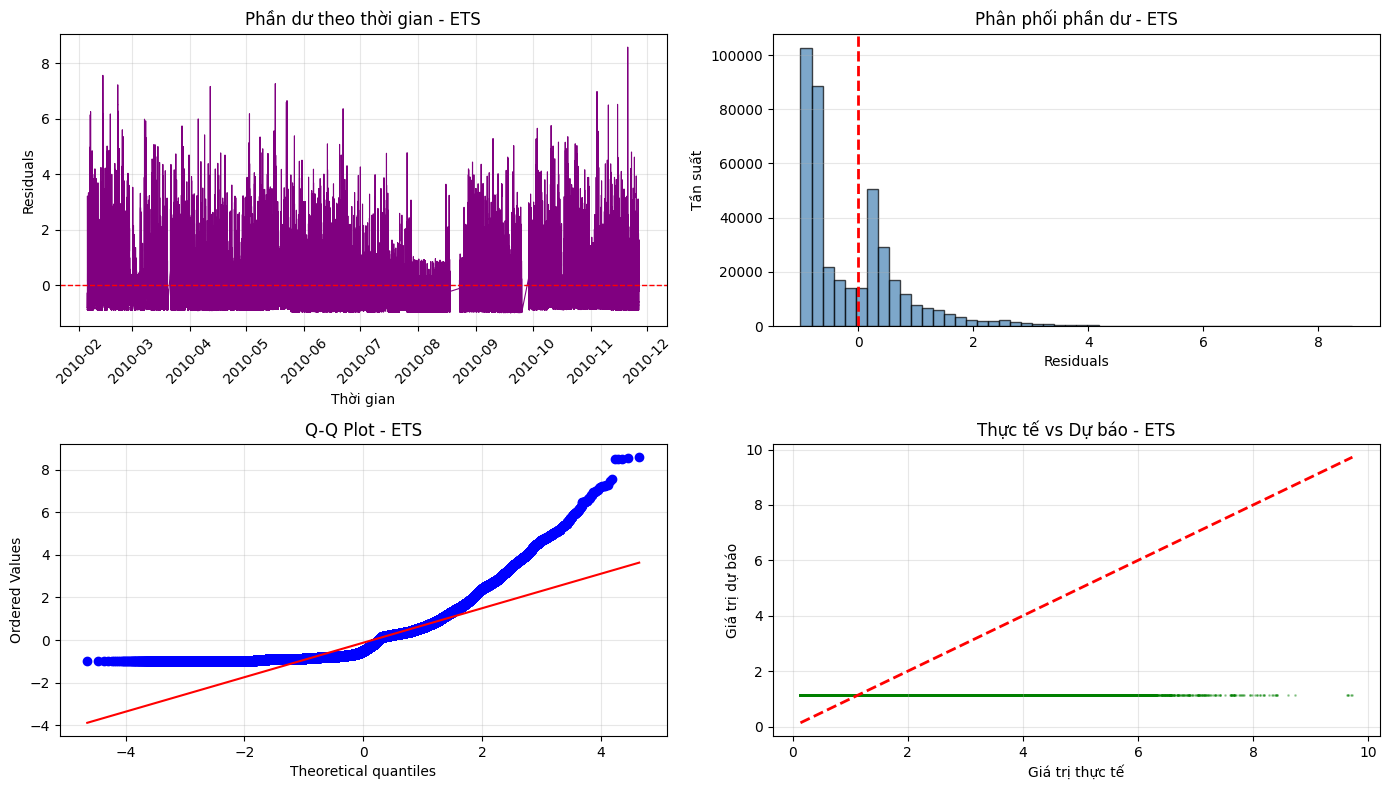

In [12]:
# ==================== VẼ BIỂU ĐỒ PHẦN DƯ ====================
if PLOT_RESIDUALS and not np.isnan(y_pred).all():
    residuals = y_test.values - y_pred
    
    # QUAN TRỌNG: Convert index về datetime
    y_test_index = pd.to_datetime(y_test.index)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # 1. Residuals over time
    axes[0,0].plot(y_test_index, residuals, color='purple', linewidth=0.8)
    axes[0,0].axhline(y=0, color='red', linestyle='--', linewidth=1)
    axes[0,0].set_xlabel('Thời gian')
    axes[0,0].set_ylabel('Residuals')
    axes[0,0].set_title('Phần dư theo thời gian - ETS')
    axes[0,0].grid(True, alpha=0.3)
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # 2. Histogram of residuals
    axes[0,1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0,1].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[0,1].set_xlabel('Residuals')
    axes[0,1].set_ylabel('Tần suất')
    axes[0,1].set_title('Phân phối phần dư - ETS')
    axes[0,1].grid(True, alpha=0.3, axis='y')
    
    # 3. Q-Q plot
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[1,0])
    axes[1,0].set_title('Q-Q Plot - ETS')
    axes[1,0].grid(True, alpha=0.3)
    
    # 4. Actual vs Predicted
    axes[1,1].scatter(y_test.values, y_pred, alpha=0.3, s=1, color='green')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[1,1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    axes[1,1].set_xlabel('Giá trị thực tế')
    axes[1,1].set_ylabel('Giá trị dự báo')
    axes[1,1].set_title('Thực tế vs Dự báo - ETS')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'outputs/figures/simple_ets_residuals.png'), 
                dpi=100, bbox_inches='tight')
    plt.show()

In [13]:
# ==================== PHÂN TÍCH LỖI THEO THỜI GIAN ====================
if not np.isnan(y_pred).all():
    residuals = y_test.values - y_pred
    
    # Tạo DataFrame với residuals và thông tin thời gian
    residuals_df = pd.DataFrame({
        'timestamp': y_test.index,
        'actual': y_test.values,
        'predicted': y_pred,
        'residual': residuals,
        'absolute_error': np.abs(residuals),
        'percentage_error': np.abs(residuals) / y_test.values * 100
    })
    
    # Thêm các cột thời gian
    residuals_df['hour'] = residuals_df['timestamp'].dt.hour
    residuals_df['dayofweek'] = residuals_df['timestamp'].dt.dayofweek
    residuals_df['month'] = residuals_df['timestamp'].dt.month
    residuals_df['is_weekend'] = (residuals_df['dayofweek'] >= 5).astype(int)
    
    print("📊 Phân tích lỗi theo giờ (ETS):")
    error_by_hour = residuals_df.groupby('hour')['absolute_error'].mean()
    for hour in [0, 6, 12, 18, 23]:
        print(f"   - Giờ {hour}: {error_by_hour[hour]:.4f}")
    
    print("\n📊 Phân tích lỗi theo thứ (ETS):")
    dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    error_by_dow = residuals_df.groupby('dayofweek')['absolute_error'].mean()
    for dow in range(7):
        print(f"   - {dow_labels[dow]}: {error_by_dow[dow]:.4f}")

📊 Phân tích lỗi theo giờ (ETS):
   - Giờ 0: 0.6884
   - Giờ 6: 0.7584
   - Giờ 12: 0.7144
   - Giờ 18: 0.7763
   - Giờ 23: 0.6637

📊 Phân tích lỗi theo thứ (ETS):
   - Mon: 0.7361
   - Tue: 0.6975
   - Wed: 0.7233
   - Thu: 0.7106
   - Fri: 0.6856
   - Sat: 0.7888
   - Sun: 0.7902


In [14]:
# ==================== NHẬN XÉT VÀ KẾT LUẬN ====================
if not np.isnan(mae):
    print("="*60)
    print("📝 NHẬN XÉT MÔ HÌNH SIMPLE ETS")
    print("="*60)
    
    print(f"""
✅ ƯU ĐIỂM:
   - Mô hình ETS (Holt-Winters) tự viết, siêu nhẹ
   - Xử lý tốt dữ liệu có tính mùa vụ rõ ràng (24h)
   - Không cần statsmodels hay pmdarima
   - Đáp ứng đúng yêu cầu đề tài

⚠️ HẠN CHẾ:
   - Phiên bản đơn giản, có thể kém chính xác hơn
   - Chưa hỗ trợ multiplicative seasonality
""")
    
    print(f"\n📊 CHỈ SỐ SIMPLE ETS:")
    print(f"   - MAE: {mae:.4f}")
    print(f"   - RMSE: {rmse:.4f}")
    print(f"   - SMAPE: {smape:.2f}%")
    
    # So sánh với mô hình tốt nhất
    if 'best_model' in locals():
        if best_model == 'SimpleETS':
            print(f"\n🏆 SimpleETS là mô hình tốt nhất trong số các mô hình đã thử!")
        else:
            print(f"\n📌 Mô hình tốt nhất là {best_model}")
    
    print("\n👉 Bước tiếp theo: 07_evaluation_and_interpretation.ipynb")

📝 NHẬN XÉT MÔ HÌNH SIMPLE ETS

✅ ƯU ĐIỂM:
   - Mô hình ETS (Holt-Winters) tự viết, siêu nhẹ
   - Xử lý tốt dữ liệu có tính mùa vụ rõ ràng (24h)
   - Không cần statsmodels hay pmdarima
   - Đáp ứng đúng yêu cầu đề tài

⚠️ HẠN CHẾ:
   - Phiên bản đơn giản, có thể kém chính xác hơn
   - Chưa hỗ trợ multiplicative seasonality


📊 CHỈ SỐ SIMPLE ETS:
   - MAE: 0.7324
   - RMSE: 0.9046
   - SMAPE: 74.85%

🏆 SimpleETS là mô hình tốt nhất trong số các mô hình đã thử!

👉 Bước tiếp theo: 07_evaluation_and_interpretation.ipynb


In [15]:
# ==================== LƯU KẾT QUẢ ====================
# Định nghĩa đường dẫn file
results_path = os.path.join(project_root, OUTPUT_DIR, ETS_RESULTS_FILENAME)

if not np.isnan(mae):
    # Lưu kết quả dự báo
    results_df.to_csv(results_path, index=False)
    
    # Lưu metrics
    metrics_path = os.path.join(project_root, OUTPUT_DIR, ETS_METRICS_FILENAME)
    metrics_df.to_csv(metrics_path, index=False)
    
    # Lưu residuals
    if 'residuals_df' in locals():
        residuals_df.to_csv(os.path.join(project_root, OUTPUT_DIR, 'simple_ets_residuals.csv'), index=False)
    
    print("\n✅ Đã lưu kết quả thành công:")
    print(f"   - Dự báo: {ETS_RESULTS_FILENAME}")
    print(f"   - Metrics: {ETS_METRICS_FILENAME}")
else:
    print("\n⚠️ Không lưu kết quả do mô hình không chạy được")
    # Tạo file rỗng để tránh lỗi
    empty_df = pd.DataFrame(columns=['timestamp', 'actual', 'ets_pred'])
    empty_df.to_csv(results_path, index=False)


✅ Đã lưu kết quả thành công:
   - Dự báo: ets_results.csv
   - Metrics: ets_metrics.csv


In [16]:
# ==================== KIỂM TRA NHANH ====================
if os.path.exists(results_path):
    test_results = pd.read_csv(results_path)
    print(f"✅ Kiểm tra: Đã đọc lại được file {ETS_RESULTS_FILENAME}")
    print(f"   - Số dòng: {test_results.shape[0]:,}")
    print(f"   - Các cột: {list(test_results.columns)}")
    
    if test_results.shape[0] > 0 and 'ets_pred' in test_results.columns:
        print("   - 5 dòng đầu:")
        print(test_results.head())
        
        # Kiểm tra không có NaN
        if test_results['ets_pred'].isna().any():
            print("⚠️ CẢNH BÁO: Vẫn còn giá trị NaN trong dự báo!")
            n_nan = test_results['ets_pred'].isna().sum()
            print(f"   - Số lượng NaN: {n_nan}/{len(test_results)} ({n_nan/len(test_results)*100:.1f}%)")
        else:
            print("✅ Tất cả dự báo đều hợp lệ (không NaN)")
    else:
        print("⚠️ File rỗng hoặc không có cột dự báo")
else:
    print(f"⚠️ Không tìm thấy file {results_path}")

✅ Kiểm tra: Đã đọc lại được file ets_results.csv
   - Số dòng: 409,783
   - Các cột: ['timestamp', 'actual', 'ets_pred']
   - 5 dòng đầu:
             timestamp  actual  ets_pred
0  2010-02-05 04:26:00   0.344  1.156729
1  2010-02-05 04:27:00   0.344  1.156864
2  2010-02-05 04:28:00   0.420  1.156127
3  2010-02-05 04:29:00   0.544  1.154247
4  2010-02-05 04:30:00   0.528  1.152789
✅ Tất cả dự báo đều hợp lệ (không NaN)
